<a href="https://colab.research.google.com/github/Rushikeshaya/Generative-AI/blob/main/Practical_No_03_Autoencoder_and_Variational_Autoencoder_for_Image_Reconstruction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Environment Setup & Data Loading

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Set Device & Random Seed
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Execution Device: {device}")
torch.manual_seed(42)

# Hyperparameters
LATENT_DIM = 20
BATCH_SIZE = 128
EPOCHS = 20
LEARNING_RATE = 1e-3

# Load Fashion-MNIST Dataset
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Class Labels for Reference
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print(f"Dataset Loaded Successfully! Training samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

Execution Device: cpu
Dataset Loaded Successfully! Training samples: 60000, Test samples: 10000


#Standard Autoencoder Model Definition

In [3]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=20):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 400),
            nn.ReLU(),
            nn.Linear(400, latent_dim)
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        reconstructed = self.decoder(z)
        return reconstructed.view(-1, 1, 28, 28)

#Variational Autoencoder (VAE) Model & Loss Function

In [4]:
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()
        # Shared Encoder Feature Extractor
        self.fc1 = nn.Linear(28 * 28, 400)

        # Latent Space (Mean & Log Variance)
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 28 * 28),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = torch.relu(self.fc1(x.view(-1, 28 * 28)))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        reconstructed = self.decoder(z)
        return reconstructed.view(-1, 1, 28, 28)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


def vae_loss_function(recon_x, x, mu, logvar):
    # Binary Cross Entropy Loss
    bce_loss = nn.functional.binary_cross_entropy(
        recon_x.view(-1, 28 * 28), x.view(-1, 28 * 28), reduction='sum'
    )
    # KL Divergence Loss
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return bce_loss + kld_loss

#Model Training Loop Execution

In [5]:
# Instantiate Models & Optimizers
ae_model = Autoencoder(LATENT_DIM).to(device)
vae_model = VAE(LATENT_DIM).to(device)

optimizer_ae = optim.Adam(ae_model.parameters(), lr=LEARNING_RATE)
optimizer_vae = optim.Adam(vae_model.parameters(), lr=LEARNING_RATE)
criterion_ae = nn.MSELoss(reduction='sum')

# --- 1. Train Autoencoder ---
print("  Training AE on Fashion-MNIST Dataset      ")
for epoch in range(1, EPOCHS + 1):
    ae_model.train()
    total_ae_loss = 0
    for images, _ in train_loader:
        images = images.to(device)
        optimizer_ae.zero_grad()
        reconstructed = ae_model(images)
        loss = criterion_ae(reconstructed, images)
        loss.backward()
        optimizer_ae.step()
        total_ae_loss += loss.item()

    avg_loss = total_ae_loss / len(train_loader.dataset)
    print(f"AE Epoch [{epoch:02d}/{EPOCHS}] | Loss: {avg_loss:.4f}")

# --- 2. Train Variational Autoencoder ---
print("  Training VAE on Fashion-MNIST Dataset     ")
for epoch in range(1, EPOCHS + 1):
    vae_model.train()
    total_vae_loss = 0
    for images, _ in train_loader:
        images = images.to(device)
        optimizer_vae.zero_grad()
        reconstructed, mu, logvar = vae_model(images)
        loss = vae_loss_function(reconstructed, images, mu, logvar)
        loss.backward()
        optimizer_vae.step()
        total_vae_loss += loss.item()

    avg_loss = total_vae_loss / len(train_loader.dataset)
    print(f"VAE Epoch [{epoch:02d}/{EPOCHS}] | Loss: {avg_loss:.4f}")

  Training AE on Fashion-MNIST Dataset      
AE Epoch [01/20] | Loss: 22.2012
AE Epoch [02/20] | Loss: 11.7986
AE Epoch [03/20] | Loss: 10.2679
AE Epoch [04/20] | Loss: 9.5095
AE Epoch [05/20] | Loss: 9.0453
AE Epoch [06/20] | Loss: 8.7393
AE Epoch [07/20] | Loss: 8.5085
AE Epoch [08/20] | Loss: 8.3247
AE Epoch [09/20] | Loss: 8.1779
AE Epoch [10/20] | Loss: 8.0535
AE Epoch [11/20] | Loss: 7.9409
AE Epoch [12/20] | Loss: 7.8555
AE Epoch [13/20] | Loss: 7.7704
AE Epoch [14/20] | Loss: 7.7008
AE Epoch [15/20] | Loss: 7.6369
AE Epoch [16/20] | Loss: 7.5782
AE Epoch [17/20] | Loss: 7.5293
AE Epoch [18/20] | Loss: 7.4760
AE Epoch [19/20] | Loss: 7.4365
AE Epoch [20/20] | Loss: 7.3936
  Training VAE on Fashion-MNIST Dataset     
VAE Epoch [01/20] | Loss: 284.9457
VAE Epoch [02/20] | Loss: 255.2121
VAE Epoch [03/20] | Loss: 249.8896
VAE Epoch [04/20] | Loss: 247.2540
VAE Epoch [05/20] | Loss: 245.6664
VAE Epoch [06/20] | Loss: 244.6118
VAE Epoch [07/20] | Loss: 243.9107
VAE Epoch [08/20] | Lo

#Visualization & Image Comparison

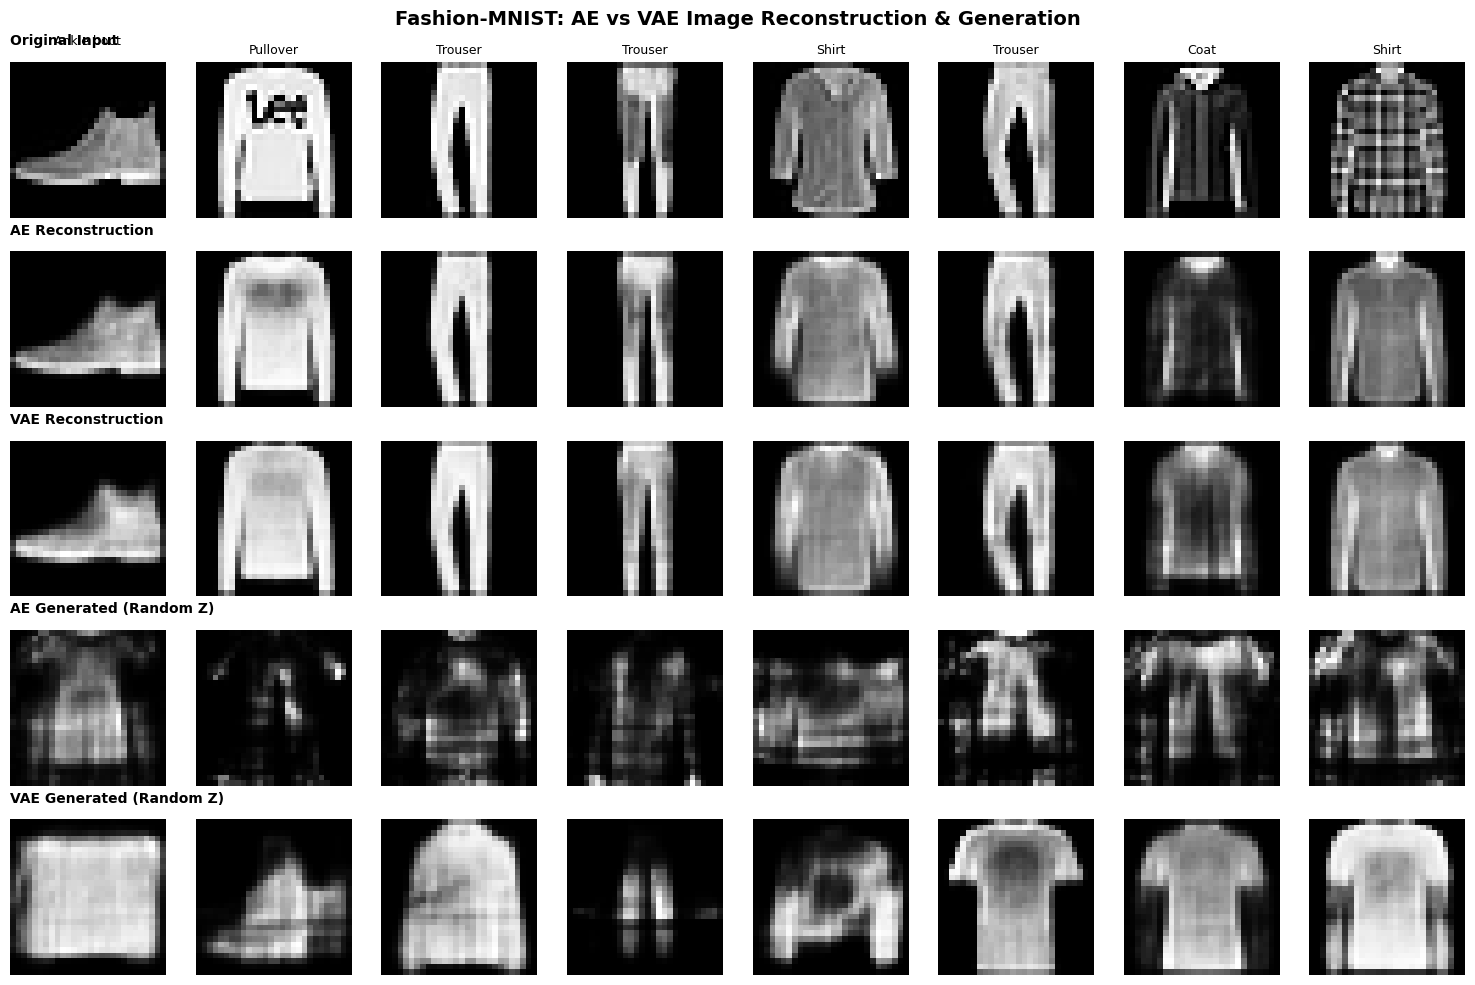

In [6]:
ae_model.eval()
vae_model.eval()

# Retrieve sample test items
test_images, labels = next(iter(test_loader))
test_images = test_images[:8].to(device)

with torch.no_grad():
    # Reconstructions
    ae_reconstructed = ae_model(test_images).cpu()
    vae_reconstructed, _, _ = vae_model(test_images)
    vae_reconstructed = vae_reconstructed.cpu()

    # Generative Sampling from Latent Gaussian z ~ N(0, I)
    random_z = torch.randn(8, LATENT_DIM).to(device)
    ae_generated = ae_model.decoder(random_z).view(-1, 1, 28, 28).cpu()
    vae_generated = vae_model.decode(random_z).cpu()

test_images = test_images.cpu()

# Plot Setup
fig, axes = plt.subplots(5, 8, figsize=(15, 10))
fig.suptitle("Fashion-MNIST: AE vs VAE Image Reconstruction & Generation", fontsize=14, fontweight='bold')

row_titles = [
    "Original Input",
    "AE Reconstruction",
    "VAE Reconstruction",
    "AE Generated (Random Z)",
    "VAE Generated (Random Z)"
]
image_batches = [test_images, ae_reconstructed, vae_reconstructed, ae_generated, vae_generated]

for row_idx, batch in enumerate(image_batches):
    for col_idx in range(8):
        ax = axes[row_idx, col_idx]
        ax.imshow(batch[col_idx].squeeze(), cmap='gray')
        ax.axis('off')
        if row_idx == 0:
            ax.set_title(class_names[labels[col_idx]], fontsize=9)
        if col_idx == 0:
            ax.set_title(row_titles[row_idx], loc='left', fontsize=10, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()